In [1]:
!pip install -q swig
!pip install -q "gymnasium[box2d]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.2 MB/s eta 0:00:00


In [2]:
import math
import random
from collections import deque
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt


In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_layers: list[int]):
        super().__init__()
        layers = []
        in_dim = state_dim
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers.append(nn.Linear(in_dim, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [4]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_layers: list[int]):
        super().__init__()
        layers = []
        in_dim = state_dim
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        self.feature = nn.Sequential(*layers)
        self.value_head = nn.Linear(in_dim, 1)
        self.adv_head = nn.Linear(in_dim, action_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.feature(x)
        v = self.value_head(h)
        a = self.adv_head(h)
        return v + a - a.mean(dim=1, keepdim=True)

In [5]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, sigma_init: float = 0.17):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.sigma_init = sigma_init

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer("weight_eps", torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer("bias_eps", torch.empty(out_features))

        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self) -> None:
        mu_range = 1.0 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.sigma_init / math.sqrt(self.in_features))
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.sigma_init / math.sqrt(self.out_features))

    @staticmethod
    def _scale_noise(size: int) -> torch.Tensor:
        x = torch.randn(size)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self) -> None:
        eps_in = self._scale_noise(self.in_features)
        eps_out = self._scale_noise(self.out_features)
        self.weight_eps.copy_(eps_out.ger(eps_in))
        self.bias_eps.copy_(eps_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            w = self.weight_mu + self.weight_sigma * self.weight_eps
            b = self.bias_mu + self.bias_sigma * self.bias_eps
        else:
            w = self.weight_mu
            b = self.bias_mu
        return F.linear(x, w, b)

In [6]:
class NoisyQNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_layers: list[int]):
        super().__init__()
        layers = []
        in_dim = state_dim
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        self.feature = nn.Sequential(*layers)
        self.noisy_out = NoisyLinear(in_dim, action_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.noisy_out(self.feature(x))

    def reset_noise(self) -> None:
        self.noisy_out.reset_noise()

In [7]:
class ReplayBuffer:
    def __init__(self, capacity: int = 50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done, gamma_n):
        self.buffer.append((state, action, reward, next_state, done, gamma_n))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d, gn = zip(*batch)
        return (np.array(s, dtype=np.float32),
                np.array(a, dtype=np.int64),
                np.array(r, dtype=np.float32),
                np.array(ns, dtype=np.float32),
                np.array(d, dtype=np.float32),
                np.array(gn, dtype=np.float32),
                None, None)

    def update_priorities(self, idxs, prios) -> None:
        pass

    def __len__(self) -> int:
        return len(self.buffer)

In [8]:
class SumTree:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float64)
        self.data = np.empty(capacity, dtype=object)
        self.write = 0
        self.size = 0

    def _propagate(self, idx: int, change: float) -> None:
        parent = (idx - 1) // 2
        self.tree[parent] += change
        if parent != 0:
            self._propagate(parent, change)

    def _retrieve(self, idx: int, s: float) -> int:
        left = 2 * idx + 1
        right = left + 1
        if left >= len(self.tree):
            return idx
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        return self._retrieve(right, s - self.tree[left])

    def total(self) -> float:
        return float(self.tree[0])

    def add(self, p: float, data) -> None:
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, p)
        self.write = (self.write + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update(self, idx: int, p: float) -> None:
        change = p - self.tree[idx]
        self.tree[idx] = p
        self._propagate(idx, change)

    def get(self, s: float):
        idx = self._retrieve(0, s)
        data_idx = idx - self.capacity + 1
        return idx, float(self.tree[idx]), self.data[data_idx]

In [9]:
class PrioritizedReplayBuffer:
    def __init__(
        self,
        capacity: int = 50000,
        alpha: float = 0.6,
        beta_start: float = 0.4,
        beta_frames: int = 100000,
        eps: float = 1e-6,
    ):
        self.tree = SumTree(capacity)
        self.capacity = capacity
        self.alpha = alpha
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.eps = eps
        self.max_prio = 1.0
        self.frame = 1

    def push(self, state, action, reward, next_state, done, gamma_n) -> None:
        p = self.max_prio ** self.alpha
        self.tree.add(p, (state, action, reward, next_state, done, gamma_n))

    def sample(self, batch_size: int):
        idxs, batch, prios = [], [], []
        segment = self.tree.total() / batch_size
        beta = min(1.0, self.beta_start + (1.0 - self.beta_start) * self.frame / self.beta_frames)
        self.frame += 1
        for i in range(batch_size):
            a, b = segment * i, segment * (i + 1)
            s = random.uniform(a, b)
            idx, p, data = self.tree.get(s)
            idxs.append(idx)
            batch.append(data)
            prios.append(p)
        probs = np.array(prios, dtype=np.float64) / max(self.tree.total(), 1e-8)
        weights = (self.tree.size * probs) ** (-beta)
        weights /= weights.max()

        s, a, r, ns, d, gn = zip(*batch)
        return (np.array(s, dtype=np.float32),
                np.array(a, dtype=np.int64),
                np.array(r, dtype=np.float32),
                np.array(ns, dtype=np.float32),
                np.array(d, dtype=np.float32),
                np.array(gn, dtype=np.float32),
                idxs,
                np.array(weights, dtype=np.float32))

    def update_priorities(self, idxs, td_errors) -> None:
        for idx, err in zip(idxs, td_errors):
            p = abs(float(err)) + self.eps
            self.max_prio = max(self.max_prio, p)
            self.tree.update(idx, p ** self.alpha)

    def __len__(self) -> int:
        return self.tree.size

In [10]:
class DQNAgent:
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        hidden_layers: list[int],
        gamma: float = 0.99,
        lr: float = 5e-4,
        batch_size: int = 64,
        buffer_capacity: int = 50000,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay: float = 0.995,
        tau: float = 0.005,
        sticky_steps: int = 1,
        device: str = "cpu",
        use_prioritized: bool = False,
        use_dueling: bool = False,
        use_noisy: bool = False,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.use_prioritized = use_prioritized
        self.use_noisy = use_noisy
        self.epsilon = 0.0 if use_noisy else epsilon_start
        self.epsilon_end = 0.0 if use_noisy else epsilon_end
        self.epsilon_decay = epsilon_decay
        self.device = torch.device(device)
        self.sticky_steps = max(1, sticky_steps)
        self._sticky_remaining = 0
        self._sticky_action = 0

        if use_noisy:
            Net = NoisyQNetwork
        elif use_dueling:
            Net = DuelingQNetwork
        else:
            Net = QNetwork

        self.policy_net = Net(state_dim, action_dim, hidden_layers).to(self.device)
        self.target_net = Net(state_dim, action_dim, hidden_layers).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

        if use_prioritized:
            self.buffer = PrioritizedReplayBuffer(buffer_capacity)
        else:
            self.buffer = ReplayBuffer(buffer_capacity)

    def select_action(self, state: np.ndarray) -> int:
        if self.use_noisy:
            with torch.no_grad():
                s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
                return int(self.policy_net(s).argmax(dim=1).item())

        if self._sticky_remaining > 0:
            self._sticky_remaining -= 1
            return self._sticky_action

        if random.random() < self.epsilon:
            self._sticky_action = random.randrange(self.action_dim)
            self._sticky_remaining = self.sticky_steps - 1
            return self._sticky_action

        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.policy_net(s).argmax(dim=1).item())

    def reset_sticky(self) -> None:
        self._sticky_remaining = 0

    def _soft_update_target(self) -> None:
        with torch.no_grad():
            for tp, pp in zip(self.target_net.parameters(), self.policy_net.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * pp.data)

    def update(self) -> float | None:
        if len(self.buffer) < self.batch_size:
            return None

        s, a, r, ns, d, gn, idxs, w = self.buffer.sample(self.batch_size)
        s = torch.tensor(s, device=self.device)
        a = torch.tensor(a, device=self.device).unsqueeze(1)
        r = torch.tensor(r, device=self.device)
        ns = torch.tensor(ns, device=self.device)
        d = torch.tensor(d, device=self.device)
        gn = torch.tensor(gn, device=self.device)

        q = self.policy_net(s).gather(1, a).squeeze(1)

        with torch.no_grad():
            next_actions = self.policy_net(ns).argmax(dim=1, keepdim=True)
            next_q = self.target_net(ns).gather(1, next_actions).squeeze(1)
            target = r + gn * next_q * (1.0 - d)

        td_error = q - target
        if self.use_prioritized:
            w_t = torch.tensor(w, device=self.device)
            loss = (w_t * F.smooth_l1_loss(q, target, reduction="none")).mean()
        else:
            loss = F.smooth_l1_loss(q, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        if self.use_prioritized:
            self.buffer.update_priorities(idxs, td_error.detach().cpu().numpy())

        self._soft_update_target()
        return loss.item()

    def decay_epsilon(self) -> None:
        if not self.use_noisy:
            self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [11]:
def _push_nstep(buffer, n_buf: deque, gamma: float) -> None:
    R = 0.0
    for i, t in enumerate(n_buf):
        R += (gamma ** i) * t[2]
    s0, a0, _, _, _ = n_buf[0]
    _, _, _, ns_last, d_last = n_buf[-1]
    g_eff = gamma ** len(n_buf)
    buffer.push(s0, a0, R, ns_last, d_last, g_eff)

def smooth(data: list[float], window: int = 20) -> np.ndarray:
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode="valid")

def mc_reward_shape(state, next_state, reward, done, gamma):
    pos0, vel0 = state
    pos1, vel1 = next_state
    phi_old = 10.0 * np.sin(3.0 * pos0) + 500.0 * (vel0 ** 2)
    phi_new = 10.0 * np.sin(3.0 * pos1) + 500.0 * (vel1 ** 2)
    return reward + gamma * phi_new * (0.0 if done else 1.0) - phi_old

In [12]:
def train(
    env_id: str,
    variant: str,
    n_episodes: int,
    hidden_layers: list[int] = [128, 128],
    gamma: float = 0.99,
    lr: float = 5e-4,
    epsilon_decay: float = 0.99,
    tau: float = 0.005,
    n_step: int = 5,
    sticky_steps: int = 1,
    batch_size: int = 128,
    buffer_capacity: int = 100000,
    update_freq: int = 4,
    reward_shaping_fn=None,
    seed: int = 42,
) -> list[float]:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(env_id)
    env.action_space.seed(seed)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    flags = dict(use_prioritized = (variant == "prioritized"), use_dueling = (variant == "dueling"), use_noisy = (variant == "noisy"))

    agent = DQNAgent(
        state_dim = state_dim,
        action_dim = action_dim,
        hidden_layers = hidden_layers,
        gamma = gamma,
        lr = lr,
        epsilon_decay = epsilon_decay,
        tau = tau,
        sticky_steps = sticky_steps,
        batch_size = batch_size,
        buffer_capacity = buffer_capacity,
        **flags,
    )

    rewards: list[float] = []
    n_buf: deque = deque(maxlen=n_step)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        agent.reset_sticky()
        if agent.use_noisy:
            agent.policy_net.reset_noise()

        total_raw = 0.0
        done = False
        step = 0
        n_buf.clear()

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_raw += reward

            shaped_r = reward
            if reward_shaping_fn is not None:
                shaped_r = reward_shaping_fn(state, next_state, reward, done, gamma)

            n_buf.append((state, action, shaped_r, next_state, float(done)))

            if len(n_buf) == n_step or done:
                _push_nstep(agent.buffer, n_buf, gamma)

            if done:
                while len(n_buf) > 1:
                    n_buf.popleft()
                    _push_nstep(agent.buffer, n_buf, gamma)
                n_buf.clear()

            step += 1
            if step % update_freq == 0:
                agent.update()
            state = next_state

        agent.decay_epsilon()
        rewards.append(total_raw)
    env.close()
    return rewards

In [13]:
WINDOW = 20

VARIANTS = ["prioritized", "dueling", "noisy"]
VARIANT_LABELS = {
    "prioritized": "Prioritized Replay",
    "dueling": "Dueling Network",
    "noisy": "Noisy Net",
}

LL_KWARGS = dict(
    env_id = "LunarLander-v3",
    n_episodes = 1000,
    hidden_layers = [256, 128],
)

MC_KWARGS = dict(
    env_id = "MountainCar-v0",
    n_episodes = 1000,
    hidden_layers = [256, 128, 64],
    lr = 1e-3,
    sticky_steps = 4,
    update_freq = 2,
    reward_shaping_fn = mc_reward_shape,
)

In [14]:
print("Эксперимент 1: LunarLander-v3")
ll_results: dict[str, list[float]] = {}
for v in VARIANTS:
    print(f"Обучение: {VARIANT_LABELS[v]}")
    ll_results[v] = train(variant=v, **LL_KWARGS)
    print(f"Результат: (ср. посл. {WINDOW} эп.) = "
          f"{np.mean(ll_results[v][-WINDOW:]):.1f}")

Эксперимент 1: LunarLander-v3
Обучение: Prioritized Replay
Результат: (ср. посл. 20 эп.) = 287.3
Обучение: Dueling Network
Результат: (ср. посл. 20 эп.) = 282.2
Обучение: Noisy Net
Результат: (ср. посл. 20 эп.) = 247.1


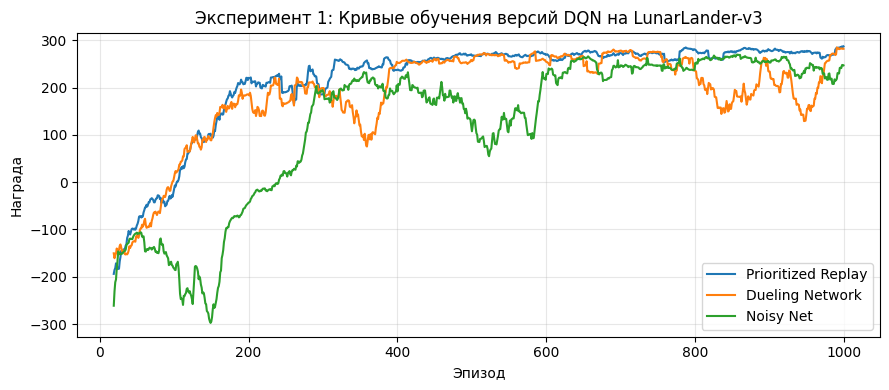

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))

for v in VARIANTS:
    rews = ll_results[v]
    s = smooth(rews, WINDOW)
    ax.plot(range(WINDOW - 1, len(rews)), s, linewidth=1.5,
            label=VARIANT_LABELS[v])

ax.set_title('Эксперимент 1: Кривые обучения версий DQN на LunarLander-v3')
ax.set_xlabel('Эпизод')
ax.set_ylabel('Награда')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print("Эксперимент 2: MountainCar-v0")
mc_results: dict[str, list[float]] = {}
for v in VARIANTS:
    print(f"Обучение: {VARIANT_LABELS[v]}")
    mc_results[v] = train(variant=v, **MC_KWARGS)
    print(f"Результат: (ср. посл. {WINDOW} эп.) = "
          f"{np.mean(mc_results[v][-WINDOW:]):.1f}")

Эксперимент 2: MountainCar-v0
Обучение: Prioritized Replay
Результат: (ср. посл. 20 эп.) = -129.9
Обучение: Dueling Network
Результат: (ср. посл. 20 эп.) = -161.4
Обучение: Noisy Net
Результат: (ср. посл. 20 эп.) = -95.8


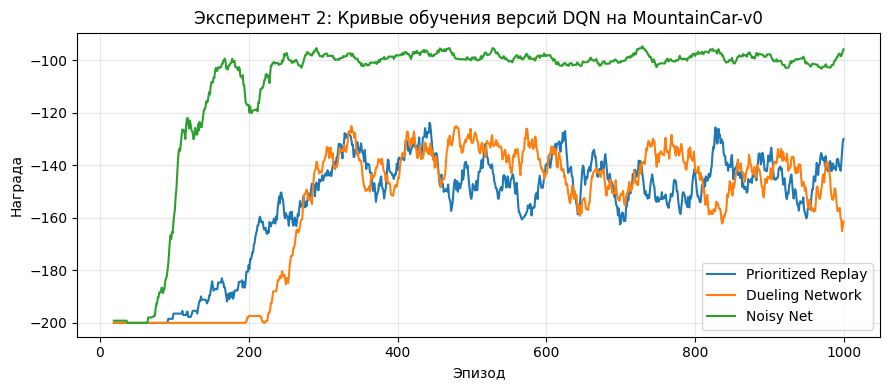

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))

for v in VARIANTS:
    rews = mc_results[v]
    s = smooth(rews, WINDOW)
    ax.plot(range(WINDOW - 1, len(rews)), s, linewidth=1.5,
            label=VARIANT_LABELS[v])

ax.set_title('Эксперимент 2: Кривые обучения версий DQN на MountainCar-v0')
ax.set_xlabel('Эпизод')
ax.set_ylabel('Награда')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print("Итоговое сравнение (среднее по последним 20 эпизодам)")
print(f"{'Модификация':<18}{'LunarLander-v3':>18}{'MountainCar-v0':>18}")
for v in VARIANTS:
    ll = np.mean(ll_results[v][-WINDOW:])
    mc = np.mean(mc_results[v][-WINDOW:])
    print(f"{VARIANT_LABELS[v]:<18}{ll:>18.1f}{mc:>18.1f}")

Итоговое сравнение (среднее по последним 20 эпизодам)
Модификация           LunarLander-v3    MountainCar-v0
Prioritized Replay             287.3            -129.9
Dueling Network                282.2            -161.4
Noisy Net                      247.1             -95.8
